In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
import os
import matplotlib.patheffects as pe
from scipy.interpolate import RegularGridInterpolator


In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


In [3]:
df_eddies_tracked = pd.read_pickle('df_eddies_tracked.pkl')
df_eddies_tracked


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,q11,q12,q22,Rc,psi0,AR,R,Age,Date,fname
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,1.227996,-0.449990,1.123684,118.032741,47.992205,1.501133,74.597458,107,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
1,1,1463,CE,160.820027,-29.753172,257,272,905.254559,1345.866439,-0.000020,...,1.231212,-0.339872,1.022306,108.004573,52.019741,1.386398,68.599374,107,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,1.393163,-0.229470,0.765331,109.827647,54.305771,1.458227,78.300764,107,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,1.274357,-0.293598,0.871468,111.650721,56.591801,1.411879,69.625773,107,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,1.302035,-0.457566,0.945071,115.925719,57.471319,1.597888,72.613632,107,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157793,3842,10646,CE,155.134295,-40.092889,223,14,711.617369,69.895295,-0.000013,...,1.184753,-0.030921,0.903800,57.890310,10.534469,1.148690,54.275882,22,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
157794,3842,10647,CE,154.883954,-40.396445,221,6,699.853461,30.349325,-0.000007,...,0.948719,-0.199901,1.216728,61.813856,10.733594,1.253634,46.817975,22,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
157795,3842,10648,CE,155.001742,-40.518521,223,4,713.016589,20.865525,-0.000007,...,0.877251,-0.200469,1.267517,65.737402,10.932719,1.306102,46.695383,22,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
157796,3842,10649,CE,155.187153,-40.282064,225,10,721.413917,51.393389,-0.000010,...,0.867521,-0.100735,1.276832,69.660948,11.131844,1.241162,47.190073,22,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...


In [4]:
df_eddies_untracked = pd.read_pickle('df_eddies_untracked.pkl')
df_eddies_untracked


,Day,Eddy,Cyc,xc,yc,lon,lat,w,Q,Omega,Rc,psi0,fname
0,1462,1,AE,829.879126,1515.297884,160.568762,-28.072350,0.015631,"[[0.7054724746035225, -0.17299518294950286], [...",0.008268,96.456316,-38.462785,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
1,1462,2,AE,357.902634,1407.794571,155.723491,-27.536492,0.031539,"[[1.2525415454561337, -0.37318304544145586], [...",0.013549,78.042405,-41.260426,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
2,1462,3,CE,928.181752,1356.070550,161.072036,-29.736582,-0.010848,"[[0.9184334895938384, -0.6568144522261018], [-...",-0.006890,118.032741,47.992205,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
3,1462,4,CE,505.750855,1353.499933,156.969877,-28.456477,-0.032406,"[[1.0915204469734063, -0.17483272531676586], [...",-0.013202,106.666574,75.106895,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
4,1462,5,AE,753.849693,1284.689807,159.168134,-29.809701,0.022045,"[[1.300245004042572, -0.37537759847059776], [-...",0.008255,103.327517,-44.066805,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
416246,10650,25,AE,348.663439,158.138527,151.457193,-38.216042,0.033157,"[[1.3863808771116255, 0.04649055064735413], [0...",0.011945,110.552001,-72.997132,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
416247,10650,26,CE,978.294053,127.970950,158.258343,-40.415935,-0.003838,"[[0.6233322936879349, -0.5502050858849237], [-...",-0.001503,75.127332,4.241051,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
416248,10650,27,AE,804.765913,95.382012,156.241400,-40.161029,0.010840,"[[1.2619918374118362, 0.3980497594289241], [0....",0.005905,60.426625,-10.779905,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
416249,10650,28,CE,157.210669,33.449590,148.933721,-38.697131,-0.007272,"[[0.9874338034387458, 0.628992620695803], [0.6...",-0.003622,141.142981,36.082072,/srv/scratch/z3533156/26year_BRAN2020/outer_av...


In [5]:
def day_plot(day, df_eddies, num_label=True):

    fnumber = 1461 + ((day - 1462) // 30)*30
    fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_{fnumber:05}.nc'
    with nc.Dataset(fname) as ds:
        ocean_time = ds['ocean_time'][:] / 86400
        t = np.where(ocean_time == day)[0][0]
        ut = ds['u_eastward'][t, -1, :, :].T
        vt = ds['v_northward'][t, -1, :, :].T

    df_day = df_eddies.loc[df_eddies.Day.eq(day)].copy()

    cs = np.hypot(ut, vt)

    fig, ax = plt.subplots(figsize=(8, 10))
    im = ax.pcolor(X_grid, Y_grid, cs, shading='nearest', vmin=0, vmax=2.5, cmap='Blues_r')
    fig.colorbar(im, ax=ax, label=r'Current speed (ms$^{-1}$)')

    clrs = np.where(df_day.Cyc.eq('CE'), 'c', 'r')
    ax.scatter(df_day.xc, df_day.yc, c=clrs, edgecolors='k', linewidths=0.8, s=60, zorder=10)

    if 'Q' not in df_day.columns:
        df_day['Q'] = list(
            np.stack([
                np.stack([df_day.q11.values, df_day.q12.values], axis=1),
                np.stack([df_day.q12.values, df_day.q22.values], axis=1)
            ], axis=1)
        )

    for xc, yc, e, Q, Rc, cyc in zip(df_day.xc, df_day.yc, df_day.Eddy, df_day.Q, df_day.Rc, df_day.Cyc):

        # ----- Where I plot the eddy's maximum tangenital velocity contour -----
        dx_ell, dy_ell = X_grid - xc, Y_grid - yc
        rho2_ell = Q[0,0]*dx_ell**2 + 2*Q[1,0]*dx_ell*dy_ell + Q[1,1]*dy_ell**2 # rho^2
        ax.contour(X_grid, Y_grid, rho2_ell, levels=[Rc**2/2], colors='r' if cyc=='AE' else 'c')

        if num_label:
            ax.annotate(
                str(e), (xc, yc),
                textcoords='offset points', xytext=(3, 3),
                fontsize=12, color='w', weight='bold',
                path_effects=[pe.withStroke(linewidth=2, foreground='k')],
                zorder=11
            )

    c1 = ax.contour(X_grid, Y_grid, lat_rho, levels=[-40, -35, -30, -25], colors='k', linewidths=.5)
    ax.clabel(c1, fmt=lambda v: f"{np.abs(v):.0f}°S", inline=True, colors='k')
    c2 = ax.contour(X_grid, Y_grid, lon_rho, levels=[150, 155, 160], colors='k', linewidths=.5)
    ax.clabel(c2, fmt=lambda v: f"{v:.0f}°E", inline=True, colors='k')
                
    ax.set_title(f'Day {day} | {pd.Timestamp("1990-01-01") + pd.Timedelta(days=day)}')
    ax.set_aspect('equal', adjustable='datalim')
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')
    ax.set_xlim(x_grid.min(), x_grid.max())
    ax.set_ylim(y_grid.min(), y_grid.max())


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


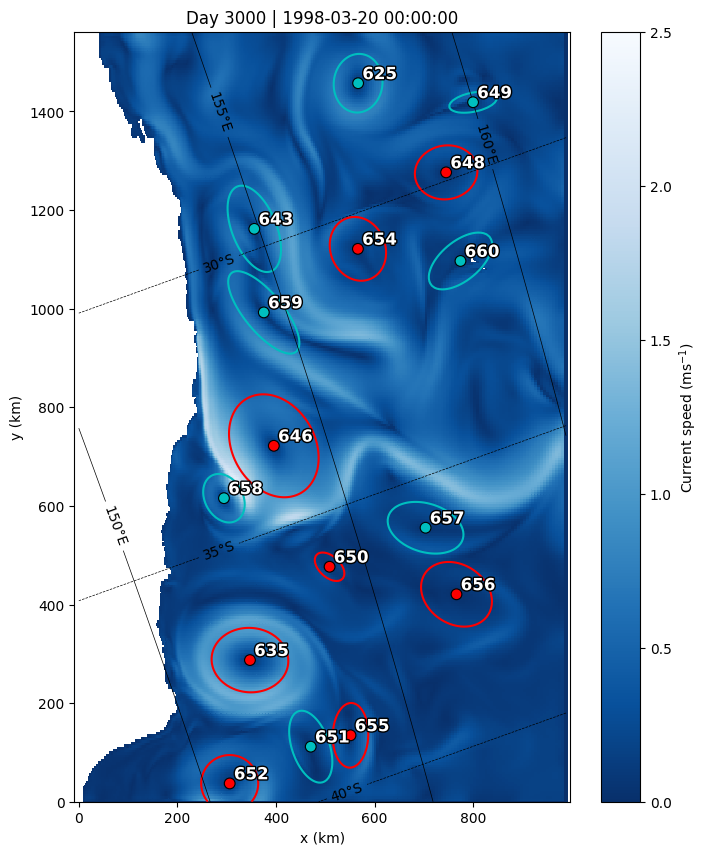

In [10]:
# Tracked dataset
day_plot(day=3000, df_eddies=df_eddies_tracked)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


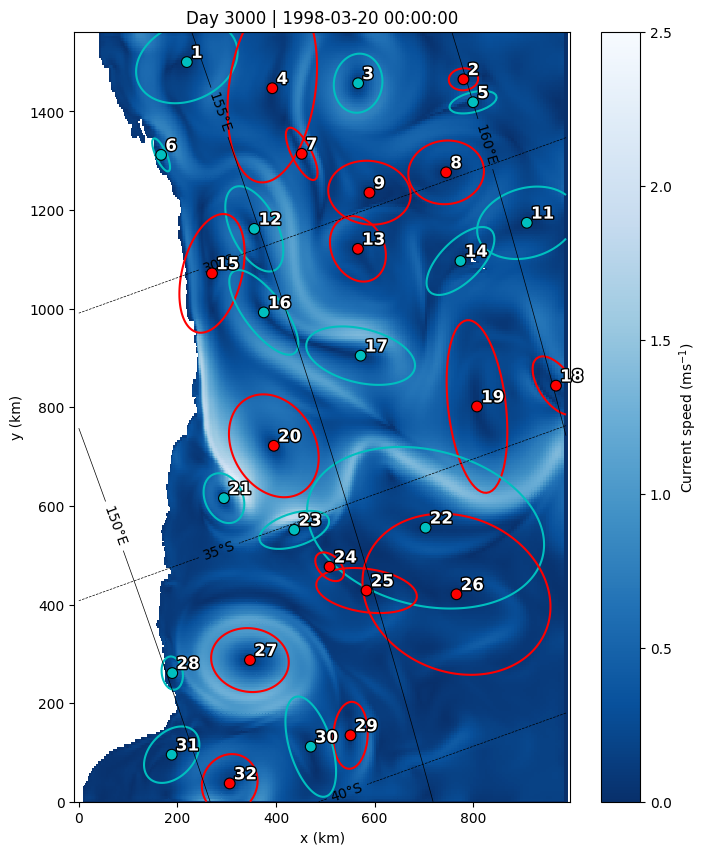

In [7]:
# Untracked dataset (i.e. original and unprocessed)
day_plot(day=3000, df_eddies=df_eddies_untracked)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


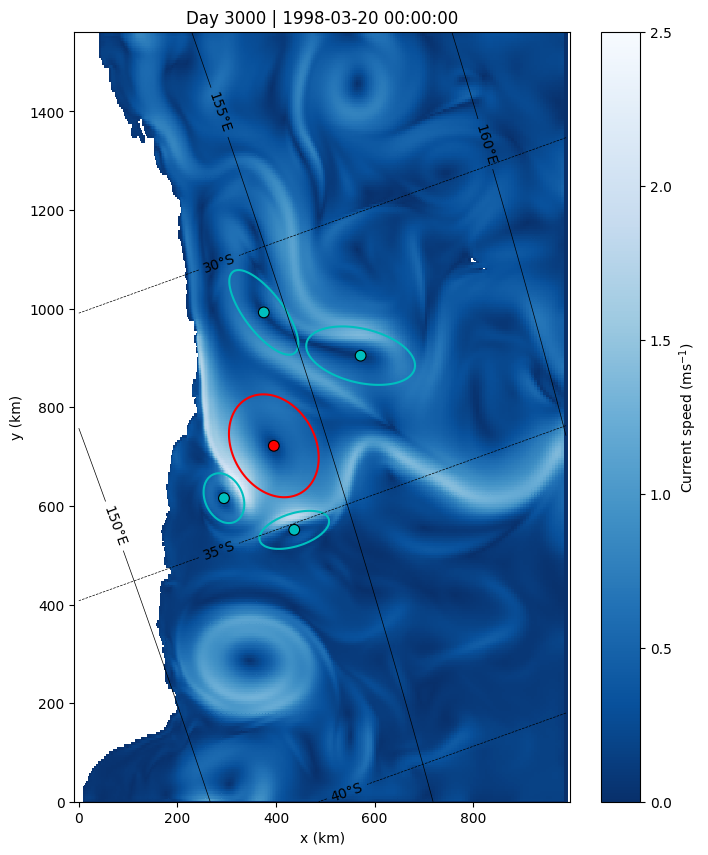

In [12]:
# If you only want to plot a couple of eddies from the above image
eddys_to_plot = [16, 17, 20, 21, 23] # choose the eddys
df = df_eddies_untracked[df_eddies_untracked.Eddy.isin(eddys_to_plot)].copy()

day_plot(day=3000, df_eddies=df, num_label=False)
